In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

import psutil
import os
import random
import time

from scipy.ndimage import median_filter, label
from cupyx.scipy.ndimage import binary_dilation

In [14]:
import math  # new: for pi^(1/3)

def print_system_mem(tag=""):
    vm = psutil.virtual_memory()
    used = vm.used / 1024**3        # used memory in GB
    avail = vm.available / 1024**3  # available memory in GB
    total = vm.total / 1024**3      # total memory in GB
    print(f"{tag} System RAM: used={used:.2f} GB, available={avail:.2f} GB, total={total:.2f} GB, percent={vm.percent:.1f}%")

print_system_mem("Before growth")



# Domain size
lx, ly, lz = 500, 500, 500
voxel_num = lx * ly * lz

# Reference growth probability Gi_ref used in the QSGS model
# Later, the effective Gi(phi_a) will be updated according to:
#   Gi(phi_a) = Gi_ref * (phi_s - 0.95 * phi_a) / (0.05 * phi_s)
G_i_ref = 8e-4

# Growth probabilities in 26 directions, initial value Gi_ref
# This array will be updated during the growth phase if Gi depends on phi_a
d = np.full(26, G_i_ref, dtype=np.float32)

# Neighbor offsets for 26 directions (3D Moore neighborhood without the center)
offsets = np.array([
    (dx, dy, dz)
    for dx in (-1, 0, 1)
    for dy in (-1, 0, 1)
    for dz in (-1, 0, 1)
    if not (dx == dy == dz == 0)
], dtype=np.int32)
assert offsets.shape[0] == 26

# Target porosity
phi = 0.1625

# Solid volume fraction phi_s
phi_solid = 1.0 - phi

# Voxel size Δ and target grain diameter d in micrometers
# Units cancel in Sd, so micrometers are convenient
voxel_size = 4.0        # Δ, voxel size in micrometers
grain_diameter = 160.0  # d, target grain diameter in micrometers

# Seed probability Sd, that is, seed volume fraction
# Formula from the paper:
#   Sd = 6 * phi_s * Δ^3 / (pi * d^3)
seed_prob = 6.0 * phi_solid * voxel_size**3 / (np.pi * grain_diameter**3)
print(f"Computed seed volume fraction Sd = {seed_prob:.3e}")

# Spacing radius in "sphere sense" (in voxel units)
# This is the R in the paper, interpreted as a spherical spacing radius
s_sphere = 30

# Convert spherical radius to an equivalent-volume octahedral (L1-ball) radius.
# For continuous shapes:
#   V_sphere = 4/3 * pi * R^3
#   V_octa   = 4/3 * a^3       for |x|+|y|+|z| <= a
# Setting V_sphere = V_octa gives a = (pi)^(1/3) * R
s_octa = int(round((math.pi ** (1.0 / 3.0)) * s_sphere))
print(f"Using equal-volume octahedral spacing radius: s_sphere = {s_sphere}, s_octa = {s_octa}")

# Maximum number of spacing rounds
n_rounds = 50

start_time = time.time()

# Compute target number of solid voxels
total_voxels = lx * ly * lz
target_solids = int((1.0 - phi) * total_voxels)
print(f"Target solid voxels: {target_solids}")

# Target seed count based on seed volume fraction Sd
target_seeds = int(seed_prob * total_voxels)
print(f"Target seed count: {target_seeds}")

# 6-neighbor structuring element; iterated s_octa times this gives a 3D L1-ball
diamond_struct = cp.zeros((3, 3, 3), dtype=cp.bool_)
diamond_struct[1, 1, 0] = True
diamond_struct[1, 1, 2] = True
diamond_struct[1, 0, 1] = True
diamond_struct[1, 2, 1] = True
diamond_struct[0, 1, 1] = True
diamond_struct[2, 1, 1] = True

# Accepted seeds and forbidden region, both stored on GPU
accepted = cp.zeros((lx, ly, lz), dtype=cp.bool_)
forbidden = cp.zeros((lx, ly, lz), dtype=cp.bool_)

for it in range(n_rounds):
    # Current number of accepted seeds
    seeds_before = int(cp.count_nonzero(accepted).get())
    remaining_seeds = target_seeds - seeds_before
    if remaining_seeds <= 0:
        print(f"Reached target seeds at round {it}, current seeds: {seeds_before}")
        break

    # Candidate base mask: voxels that are not forbidden and not already accepted
    candidate_mask_base = (~forbidden) & (~accepted)
    free_count = int(cp.count_nonzero(candidate_mask_base).get())
    if free_count == 0:
        print(f"No free voxels left at round {it}, stop.")
        break

    # Each round consumes a fixed fraction alpha of remaining seeds
    alpha = 0.2
    target_this_round = max(1, int(alpha * remaining_seeds))

    # Oversample to compensate seeds discarded by spacing constraints
    oversample_factor = 2.0
    p_raw = oversample_factor * target_this_round / free_count
    if p_raw > 1.0:
        p_raw = 1.0

    # Random sampling of candidates on GPU
    rnd = cp.random.random((lx, ly, lz))
    candidate = candidate_mask_base & (rnd < p_raw)
    num_candidates = int(cp.count_nonzero(candidate).get())

    print(
        f"Round {it + 1}, free voxels: {free_count}, "
        f"p_raw: {p_raw:.3e}, candidates: {num_candidates}"
    )

    if num_candidates == 0:
        continue

    # Add the new candidates to accepted seeds
    accepted |= candidate

    # Update forbidden region via diamond-type dilation with equal-volume radius s_octa
    forbidden = binary_dilation(
        accepted,
        structure=diamond_struct,
        iterations=s_octa,
        border_value=0
    )

    # Count seeds after this spacing round
    seeds_after = int(cp.count_nonzero(accepted).get())
    print(
        f"End of round {it + 1}, new seeds: {seeds_after - seeds_before}, "
        f"total seeds: {seeds_after}"
    )

    if seeds_after >= target_seeds:
        print(
            f"Reached target seeds at round {it + 1} during update, "
            f"current seeds: {seeds_after}"
        )
        break

# Copy accepted seed mask back to CPU
accepted_np = accepted.get()

# Write seeds back into arrgrid; subsequent growth phase uses NumPy on CPU
arrgrid = np.zeros((lx, ly, lz), dtype=np.uint8)
arrgrid[accepted_np] = 1

# Extract seed coordinates on CPU
seeds = np.argwhere(accepted_np)
num_seeds = seeds.shape[0]
print(f"Final seeds after spacing: {num_seeds}")

if num_seeds == 0:
    raise RuntimeError("No seeds generated after spacing. Adjust 'seed_prob' or s_sphere.")

# Preallocate solids array, first num_seeds rows hold initial seed coordinates
solids = np.zeros((target_solids, 3), dtype=np.int32)
for i in range(num_seeds):
    solids[i, :] = seeds[i]

elapsed = time.time() - start_time
print(f"Elapsed time: {elapsed:.2f} s")

Before growth System RAM: used=40.68 GB, available=23.13 GB, total=63.82 GB, percent=63.8%
Computed seed volume fraction Sd = 2.499e-05
Using equal-volume octahedral spacing radius: s_sphere = 30, s_octa = 44
Target solid voxels: 104687500
Target seed count: 3124
Round 1, free voxels: 125000000, p_raw: 9.984e-06, candidates: 1219
End of round 1, new seeds: 1219, total seeds: 1219
Round 2, free voxels: 72898625, p_raw: 1.045e-05, candidates: 791
End of round 2, new seeds: 791, total seeds: 2010
Round 3, free voxels: 46939809, p_raw: 9.459e-06, candidates: 450
End of round 3, new seeds: 450, total seeds: 2460
Round 4, free voxels: 34892549, p_raw: 7.566e-06, candidates: 257
End of round 4, new seeds: 257, total seeds: 2717
Round 5, free voxels: 28350155, p_raw: 5.714e-06, candidates: 174
End of round 5, new seeds: 174, total seeds: 2891
Round 6, free voxels: 24635433, p_raw: 3.734e-06, candidates: 71
End of round 6, new seeds: 71, total seeds: 2962
Round 7, free voxels: 23280814, p_raw: 

In [15]:
grow_step_code = r'''
extern "C" __global__
void grow_step(const unsigned char* arr,
               unsigned char* new_flag,
               const int* offsets,
               const double* probs,
               const double* rand,
               int lx, int ly, int lz,
               int n_dirs)
{
    // Total number of voxels in the 3D domain
    int total = lx * ly * lz;

    // Global 1D index for this thread
    int idx = blockDim.x * blockIdx.x + threadIdx.x;
    if (idx >= total) return;

    // Recover (x, y, z) from 1D index for C-order layout
    int yz  = ly * lz;
    int x   = idx / yz;
    int rem = idx % yz;
    int y   = rem / lz;
    int z   = rem % lz;

    // Already a solid voxel, no growth here in this time step
    if (arr[idx] != 0) {
        new_flag[idx] = 0;
        return;
    }

    bool   has_solid = false;
    double p_prod    = 1.0;

    // Loop over all 26 neighbor directions
    for (int k = 0; k < n_dirs; ++k) {
        int dx = offsets[3 * k + 0];
        int dy = offsets[3 * k + 1];
        int dz = offsets[3 * k + 2];

        // Use x - offsets, consistent with the CPU implementation
        int nx = x - dx;
        int ny = y - dy;
        int nz = z - dz;

        // Skip neighbors outside the domain
        if (nx < 0 || nx >= lx || ny < 0 || ny >= ly || nz < 0 || nz >= lz)
            continue;

        int nidx = nx * yz + ny * lz + nz;

        // Neighbor is solid: accumulate contribution to effective probability
        if (arr[nidx] == 1) {
            has_solid = true;
            double p = probs[k];
            p_prod *= (1.0 - p);
        }
    }

    // No solid neighbors -> no growth for this voxel
    if (!has_solid) {
        new_flag[idx] = 0;
        return;
    }

    // Effective growth probability from all solid neighbors
    double p_eff = 1.0 - p_prod;

    // Bernoulli trial with precomputed random field
    if (rand[idx] < p_eff) {
        new_flag[idx] = 1;
    } else {
        new_flag[idx] = 0;
    }
}
''';

grow_step_kernel = cp.RawKernel(grow_step_code, "grow_step")


def rebuild_solids_inplace(arrgrid, solids, lx, ly, lz):
    """
    Rebuild the 'solids' coordinate array in a memory-friendly streaming way.

    Instead of using np.argwhere(arrgrid == 1), which allocates a large
    temporary array of shape (num_solids, 3), this function scans arrgrid
    line by line and writes coordinates directly into 'solids'.

    Parameters
    ----------
    arrgrid : np.ndarray, uint8, shape (lx, ly, lz)
        Final microstructure: 1 means solid, 0 means pore.
    solids : np.ndarray, int32, shape (target_solids, 3)
        Preallocated array to store (x, y, z) coordinates of solid voxels.
    lx, ly, lz : int
        Grid dimensions.

    Returns
    -------
    count : int
        Number of coordinates actually written into 'solids'.
    """
    max_solids = solids.shape[0]
    count = 0

    for x in range(lx):
        for y in range(ly):
            # Take the z-line for fixed (x, y)
            row = arrgrid[x, y, :]
            # Indices of solid voxels along this line in z
            nz = np.nonzero(row)[0]
            k = nz.shape[0]
            if k == 0:
                continue

            # Avoid overflow of the preallocated solids array
            if count + k > max_solids:
                k = max_solids - count
                if k <= 0:
                    return max_solids

            solids[count:count + k, 0] = x
            solids[count:count + k, 1] = y
            solids[count:count + k, 2] = nz[:k]
            count += k

            # Solids array is full
            if count >= max_solids:
                return max_solids

    return count


def grow_phase_gpu(arrgrid, solids, count, offsets, probs, target, lx, ly, lz):
    """
    GPU explicit-time QSGS growth in FP64 with memory-friendly solids rebuilding.

    QSGS growth probability is adapted according to
        Gi(phi_a) = Gi_ref * (phi_s - 0.95 * phi_a) / (0.05 * phi_s)
    where
        phi_a is the actual solid volume fraction at current step
        phi_s = 1 - phi is the target solid fraction
        Gi_ref is the reference growth probability.

    Steps:
      1. Flatten 3D grid to 1D on GPU (C-order layout).
      2. For each explicit time step:
         - Compute Gi(phi_a) from the formula above.
         - Fill directional probabilities probs_gpu with Gi(phi_a) in FP64.
         - Generate a random field in FP64.
         - Launch 'grow_step' kernel to decide which pores become solid.
         - Accept either all or a subset of newly grown voxels to reach
           the target solid count.
      3. After the growth loop finishes, synchronize and print system RAM usage.
      4. Copy the flattened grid back to 3D array on CPU.
      5. Rebuild the 'solids' coordinate list in a streaming fashion to avoid
         large temporary allocations.

    Parameters
    ----------
    arrgrid : np.ndarray, uint8, shape (lx, ly, lz)
        Initial microstructure on CPU (1 means solid, 0 means pore).
    solids : np.ndarray, int32, shape (target_solids, 3)
        Preallocated coordinate array, filled after growth.
    count : int
        Initial number of solid voxels (recomputed on GPU inside this function).
    offsets : np.ndarray, int32, shape (26, 3)
        Direction offsets for the QSGS neighborhood.
    probs : np.ndarray, float64, shape (26,)
        Directional growth probabilities (initially set to Gi_ref).
    target : int
        Target number of solid voxels.
    lx, ly, lz : int
        Domain size.

    Returns
    -------
    arrgrid : np.ndarray, uint8
        Final microstructure after growth on CPU.
    num_solids : int
        Number of entries in 'solids' that were filled.
    """
    total_voxels = lx * ly * lz

    # Flatten 3D grid to 1D for better coalesced memory access on GPU
    arr_flat = cp.asarray(arrgrid.ravel(order="C"), dtype=cp.uint8)

    # Flatten offsets to [dx0, dy0, dz0, dx1, dy1, dz1, ...]
    offsets_gpu = cp.asarray(offsets.reshape(-1), dtype=cp.int32)

    # Directional probabilities in FP64
    probs_gpu = cp.asarray(probs, dtype=cp.float64)

    # Flag array: 1 if the voxel becomes solid in this time step, else 0
    new_flag = cp.zeros(total_voxels, dtype=cp.uint8)

    n_dirs = offsets.shape[0]
    threads_per_block = 256
    blocks = (total_voxels + threads_per_block - 1) // threads_per_block

    # Recompute initial number of solid voxels from GPU data
    count = int(cp.sum(arr_flat).get())

    # Explicit-time growth loop
    while count < target:
        # Current actual solid volume fraction phi_a = Va / Vtotal
        phi_a = float(count) / float(total_voxels)

        # Solid volume fraction phi_s based on the target porosity phi
        # phi and G_i_ref are global variables defined in the seeding code
        phi_s = 1.0 - phi

        # QSGS growth probability Gi(phi_a):
        #   Gi(phi_a) = Gi_ref * (phi_s - 0.95 * phi_a) / (0.05 * phi_s)
        Gi = G_i_ref * (phi_s - 0.95 * phi_a) / (0.05 * phi_s)

        # Clamp Gi to non negative values for stability
        if Gi < 0.0:
            Gi = 0.0

        # Update directional growth probabilities on GPU in FP64
        # Here all 26 directions share the same scalar Gi(phi_a)
        probs_gpu.fill(np.float64(Gi))

        # Random field (FP64) for this step, one random number per voxel
        rand_field = cp.random.random(total_voxels, dtype=cp.float64)

        # Reset the new_flag array for the current step
        new_flag.fill(0)

        # Launch the custom CUDA kernel to compute new_flag
        grow_step_kernel(
            (blocks,), (threads_per_block,),
            (arr_flat, new_flag,
             offsets_gpu, probs_gpu, rand_field,
             lx, ly, lz, n_dirs)
        )

        # Number of newly grown voxels in this step
        new_count = int(cp.count_nonzero(new_flag).get())
        if new_count == 0:
            break

        remaining = target - count

        if new_count <= remaining:
            # Accept all newly grown voxels
            arr_flat[new_flag == 1] = 1
            count += new_count
        else:
            # Accept only a subset so that the total equals 'target'
            idxs = cp.where(new_flag == 1)[0]
            perm = cp.random.permutation(idxs.shape[0])
            keep = idxs[perm[:remaining]]
            arr_flat[keep] = 1
            count += remaining
            break

    # Ensure all GPU work is completed before measuring memory
    cp.cuda.Stream.null.synchronize()
    print_system_mem("After growth")

    # Copy the 1D flattened array back to the 3D CPU grid
    arrgrid[:, :, :] = cp.asnumpy(arr_flat.reshape(lx, ly, lz))

    # Memory-friendly rebuild of 'solids' coordinates
    num_solids = rebuild_solids_inplace(arrgrid, solids, lx, ly, lz)

    return arrgrid, num_solids


# Call GPU version
use_gpu = True
count = num_seeds

print("Using GPU grow_phase_gpu")
start_time = time.time()
arrgrid, final_count = grow_phase_gpu(arrgrid, solids, count, offsets, d, target_solids, lx, ly, lz)
elapsed = time.time() - start_time

computational_speed = total_voxels / elapsed

print(f"Growth complete: total solids = {final_count}")
print(f"Elapsed time (growth): {elapsed:.2f} s")
print(f"Computational Speed: {computational_speed:.2f} node/s")

Using GPU grow_phase_gpu
After growth System RAM: used=39.50 GB, available=24.32 GB, total=63.82 GB, percent=61.9%
Growth complete: total solids = 104687500
Elapsed time (growth): 18.15 s
Computational Speed: 6886602.44 node/s


In [16]:
# Median filter to smooth geometry
arrgrid = median_filter(arrgrid, size=3)

# Porosity check
total_solid = arrgrid.sum()
porosity = 1 - total_solid / total_voxels
print(f"Porosity after filtering: {porosity:.4f}")

# Connectivity analysis
copy_grid = arrgrid.copy()
structure = np.ones((3, 3, 3), dtype=np.uint8)
labels, num_features = label(copy_grid == 0, structure=structure)
print(f"Detected {num_features} pore regions before removal.")

# Removal of isolated pore regions
# Find labels on inlet (z=0) and outlet (z=lz-1) planes
inlet_labels = np.unique(labels[:, :, 0][labels[:, :, 0] > 0])
outlet_labels = np.unique(labels[:, :, lz-1][labels[:, :, lz-1] > 0])

#Intersect to get connected region labels
good_labels = np.intersect1d(inlet_labels, outlet_labels)

# Mask and remove isolated pores
mask_remove = (labels > 0) & (~np.isin(labels, good_labels))
copy_grid[mask_remove] = 1

# Compute connected porosity ratio
connected_ratio = np.count_nonzero(copy_grid == 0) / total_voxels
print(f"Connected porosity ratio: {connected_ratio:.4f}")

Porosity after filtering: 0.1515
Detected 2518 pore regions before removal.
Connected porosity ratio: 0.1500


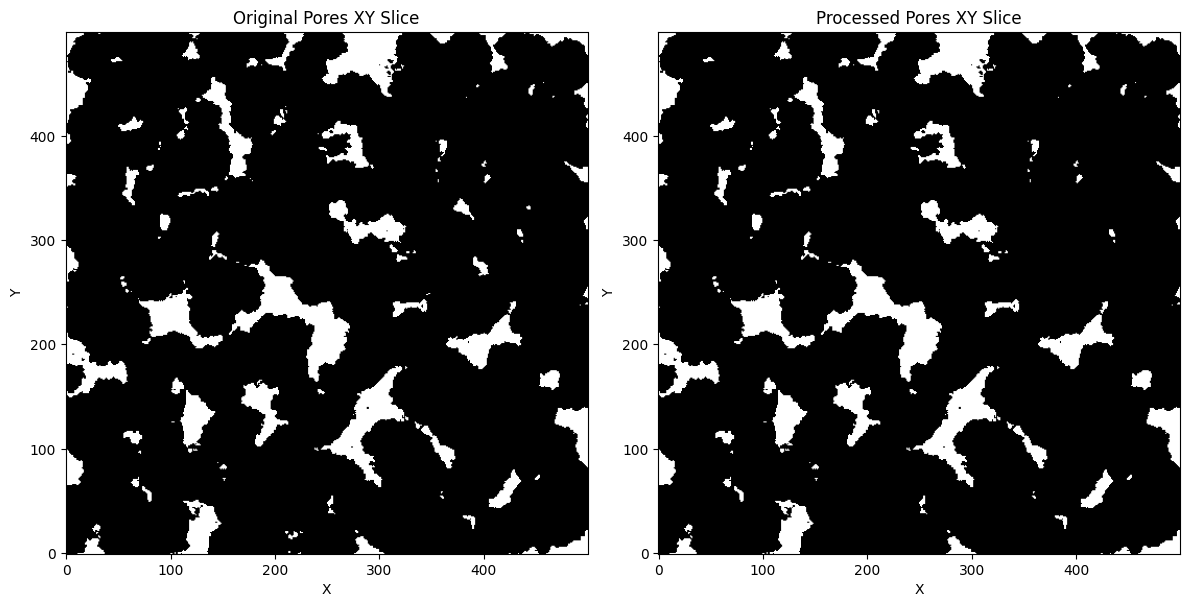

In [17]:
# 2D XY slice visualization at mid-plane
z_mid = lz // 2
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Original generated pores (arrgrid==0)
axs[0].imshow((arrgrid == 0)[:, :, z_mid].T, origin='lower', cmap='gray')
axs[0].set_title('Original Pores XY Slice')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')

# Processed pores after connectivity removal (copy_grid==0)
axs[1].imshow((copy_grid == 0)[:, :, z_mid].T, origin='lower', cmap='gray')
axs[1].set_title('Processed Pores XY Slice')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')

plt.tight_layout()
# plt.savefig("core xy slice.png")
plt.show()

In [18]:
# Export to VTK legacy file for Paraview
vtk_filename = '500_Spacing30_phi01500.vtk'
flat_data = arrgrid.flatten(order='C')
with open(vtk_filename, 'w') as vtk_file:
    vtk_file.write(
        "# vtk DataFile Version 3.0\n"
        "QSGS 3D model output\n"
        "ASCII\n"
        "DATASET STRUCTURED_POINTS\n"
        f"DIMENSIONS {lx} {ly} {lz}\n"
        "ORIGIN 0 0 0\n"
        "SPACING 4 4 4\n"
        f"POINT_DATA {total_voxels}\n"
        "SCALARS phase unsigned_char 1\n"
        "LOOKUP_TABLE default\n"
    )
    for value in flat_data:
        vtk_file.write(f"{value}\n")
print(f"VTK file written to {vtk_filename}")

VTK file written to 500_Spacing30_phi01500.vtk


In [19]:
# Export to RAW and MHD for simple volume data
raw_filename = '500_Spacing30_phi01500.raw'
mhd_filename = '500_Spacing30_phi01500.mhd'
arrgrid.astype(np.uint8).tofile(raw_filename)
spacing = (4.0, 4.0, 4.0)
offset = (0, 0, 0)
unit = 1e-6
with open(mhd_filename, 'w') as mhd:
    mhd.write(
        "ObjectType = Image\n"
        "NDims = 3\n"
        "ElementType = MET_UCHAR\n"
        "\n"
        f"DimSize =        {lx}  {ly}  {lz}\n"
        f"ElementSpacing = {spacing[0]}   {spacing[1]}   {spacing[2]}\n"
        f"Offset =         {offset[0]}   {offset[1]}   {offset[2]}\n"
        f"Unit = {unit}\n"
        f"ElementDataFile = {raw_filename}\n"
    )
print(f"RAW file written to {raw_filename}")
print(f"MHD header written to {mhd_filename}")

RAW file written to 500_Spacing30_phi01500.raw
MHD header written to 500_Spacing30_phi01500.mhd
